###Assignment on Exploratory Data Analysis

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving superstore[1].csv to superstore[1].csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("superstore[1].csv")
df.head(2)

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4


###Q1: Data Cleaning:

i.            Count and handle Missing values.

ii.            Deal with Duplicate values

iii.           Delete unknown columns if present.

iv.           Check shape, size, and datatypes of the dataset features.

In [ ]:
#Q1. i.Count and handle Missing values.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [ ]:
df['Order.ID'].nunique()


25035

In [ ]:
df['Row.ID'].nunique()

51290

In [ ]:
df.shape

(51290, 27)

In [ ]:
df['Market'].value_counts()

,count
Market,
APAC,11002
LATAM,10294
EU,10000
US,9994
EMEA,5029
Africa,4587
Canada,384


In [ ]:
df['Market2'].value_counts()

,count
Market2,
APAC,11002
North America,10378
LATAM,10294
EU,10000
EMEA,5029
Africa,4587


##Initial Investigation


Total rows: 51,290

Columns: 27

Some categorical columns need conversion-category,city,country,order.priority,region,segment,ship mode,state,sub category,market,market 2

One unwanted column (ï»¿) must be removed

Row id column is not necessary here so it can be dropped.

Order.Date must be converted to datetime

market and market 2 is available but both shows different value counts so better to keep it like that

Shipping.Cost has 5 missing values will take median values based on shipping mode

State has 3 missing values, keep it temporarily like that



In [ ]:
#Missing values of state needs to be filled as Unknown

df['State'] = df['State'].fillna('Unknown')

In [ ]:
#conversion to categories
cat_cols = ['Category','City','Country','Order.Priority','Region',
            'Segment','Ship.Mode','State','Sub.Category','Market','Market2']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
#Q1 iii dropping an unwanted colum
df.drop(columns=['记录数'], inplace=True)

In [ ]:
#dropping row id column

df = df.drop(columns=['Row.ID'])

In [ ]:
#converting order date to date time format

df['Order.Date'] = pd.to_datetime(df['Order.Date'])

In [ ]:
#Q1 ii checking for duplicated rows
df.duplicated().sum()

np.int64(0)

In [ ]:
df[df['Shipping.Cost'].isnull()]

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
448,Office Supplies,San Francisco,United States,CM-123854,Christopher Martinez,0.0,US,2026-03-10,CA-2014-111738,Medium,...,9,Consumer,00:00.0,Standard Class,NaN,California,Art,2014,North America,1
605,Office Supplies,San Diego,United States,TH-211004,Thea Hendricks,0.0,US,2026-03-10,US-2011-133130,High,...,82,Consumer,00:00.0,Standard Class,NaN,California,Paper,2011,North America,40
854,Office Supplies,Santa Clara,United States,LR-170354,Lisa Ryan,0.0,US,2026-03-10,CA-2011-109918,Medium,...,21,Corporate,00:00.0,Second Class,NaN,California,Paper,2011,North America,37
1265,Office Supplies,New York City,United States,BD-117704,Bryan Davis,0.0,US,2026-03-10,CA-2013-124667,Medium,...,83,Consumer,00:00.0,Standard Class,NaN,New York,Storage,2013,North America,46
1465,Office Supplies,Seattle,United States,MZ-173354,Maria Zettner,0.0,US,2026-03-10,CA-2014-147144,Medium,...,20,Home Office,00:00.0,First Class,NaN,Washington,Art,2014,North America,13


In [ ]:
#Running descriptive statistics for checking outliers

df.describe()

,Discount,Order.Date,Profit,Quantity,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,2026-03-09 23:59:59.999999744,28.610982,3.476545,246.498440,26.376286,2012.777208,31.287112
min,0.000000,2026-03-10 00:00:00,-6599.978000,1.000000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,2026-03-10 00:00:00,0.000000,2.000000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,2026-03-10 00:00:00,9.240000,3.000000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,2026-03-10 00:00:00,36.810000,5.000000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,2026-03-10 00:00:00,8399.976000,14.000000,22638.000000,933.570000,2014.000000,53.000000
std,0.212280,NaN,174.340972,2.278766,487.567175,57.296640,1.098931,14.429795


In [ ]:
#imputation of median values to shipping cost basedon shipping mode
df['Shipping.Cost'] = df.groupby('Ship.Mode')['Shipping.Cost']\
                        .transform(lambda x: x.fillna(x.median()))

/tmp/ipykernel_1031/410868013.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df['Shipping.Cost'] = df.groupby('Ship.Mode')['Shipping.Cost']\


In [ ]:
#now we will analyze outliers in shipping cost
df.groupby('Ship.Mode')['Shipping.Cost'].describe()

/tmp/ipykernel_1031/3037100756.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Ship.Mode')['Shipping.Cost'].describe()


,count,mean,std,min,25%,50%,75%,max
Ship.Mode,,,,,,,,
First Class,7505.0,41.054398,80.580766,0.010,4.29,12.825,38.91,915.49
Same Day,2701.0,42.937325,85.998268,0.010,4.26,12.340,39.90,933.57
Second Class,10309.0,30.470458,64.996763,0.002,3.08,8.950,28.18,923.63
Standard Class,30775.0,19.971820,41.241890,0.003,2.18,6.340,19.45,878.38


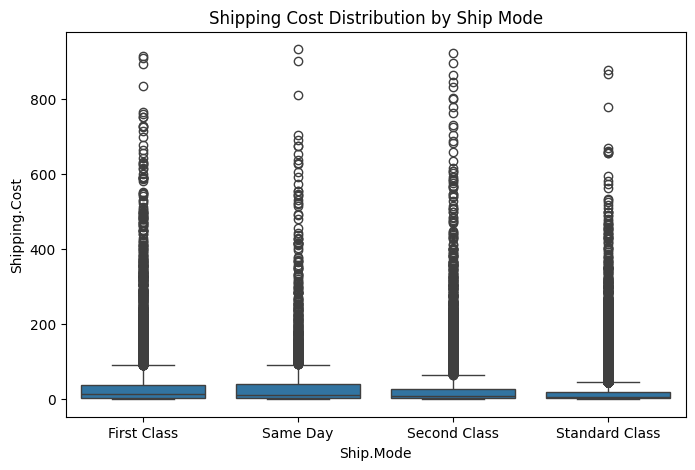

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Ship.Mode', y='Shipping.Cost', data=df)
plt.title('Shipping Cost Distribution by Ship Mode')
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  category      
 1   City            51290 non-null  category      
 2   Country         51290 non-null  category      
 3   Customer.ID     51290 non-null  object        
 4   Customer.Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  category      
 7   Order.Date      51290 non-null  datetime64[ns]
 8   Order.ID        51290 non-null  object        
 9   Order.Priority  51290 non-null  category      
 10  Product.ID      51290 non-null  object        
 11  Product.Name    51290 non-null  object        
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  category      
 15  Sa

The data cleaning is completed.Boxplots were used to inspect outliers in numerical variables such as Sales, Profit, Discount and Quantity. Outliers were observed but retained since they represent genuine business transactions rather than data errors.

In [ ]:
#saving a copy of cleaned data set for further analysis
df = df.reset_index(drop=True)
df.to_csv('cleaned_dataset.csv', index=False)

In [ ]:
#using the cleaned data set for further analysis from here onwards
from google.colab import files
uploaded=files.upload()

Saving cleaned_dataset.csv to cleaned_dataset.csv


In [ ]:
clean_df=pd.read_csv('cleaned_dataset.csv')
clean_df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,Order.Date,Order.ID,Order.Priority,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,2026-03-10,CA-2011-130813,High,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,2026-03-10,CA-2011-148614,Medium,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-03-10,CA-2011-118962,Medium,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,2026-03-10,CA-2011-118962,Medium,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,2026-03-10,CA-2011-146969,High,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   Order.Date      51290 non-null  object 
 8   Order.ID        51290 non-null  object 
 9   Order.Priority  51290 non-null  object 
 10  Product.ID      51290 non-null  object 
 11  Product.Name    51290 non-null  object 
 12  Profit          51290 non-null  float64
 13  Quantity        51290 non-null  int64  
 14  Region          51290 non-null  object 
 15  Sales           51290 non-null  int64  
 16  Segment         51290 non-null  object 
 17  Ship.Date       51290 non-null 

In [ ]:
#Shipping date also needs conversion
clean_df['Ship.Date'] = pd.to_datetime(clean_df['Ship.Date'])

In [ ]:
#order date also needs conversion
clean_df['Order.Date'] = pd.to_datetime(clean_df['Order.Date'])


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  object        
 1   City            51290 non-null  object        
 2   Country         51290 non-null  object        
 3   Customer.ID     51290 non-null  object        
 4   Customer.Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  object        
 7   Order.Date      51290 non-null  datetime64[ns]
 8   Order.ID        51290 non-null  object        
 9   Order.Priority  51290 non-null  object        
 10  Product.ID      51290 non-null  object        
 11  Product.Name    51290 non-null  object        
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  object        
 15  Sa

In [ ]:
#conversion to categories again as the cleaned data set in csv cannot have category datatype hence require converting again
cat_cols1 = ['Category','City','Country','Order.Priority','Region',
            'Segment','Ship.Mode','State','Sub.Category','Market','Market2']

for col in cat_cols1:
    clean_df[col] = clean_df[col].astype('category')

In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Category        51290 non-null  category      
 1   City            51290 non-null  category      
 2   Country         51290 non-null  category      
 3   Customer.ID     51290 non-null  object        
 4   Customer.Name   51290 non-null  object        
 5   Discount        51290 non-null  float64       
 6   Market          51290 non-null  category      
 7   Order.Date      51290 non-null  datetime64[ns]
 8   Order.ID        51290 non-null  object        
 9   Order.Priority  51290 non-null  category      
 10  Product.ID      51290 non-null  object        
 11  Product.Name    51290 non-null  object        
 12  Profit          51290 non-null  float64       
 13  Quantity        51290 non-null  int64         
 14  Region          51290 non-null  category      
 15  Sa

##Q2: Perform Univariate Analysis across all numerical features,

 i.            Which features seem useless in the analysis? Explain why?

ii.            Which features are uniformly distributed or normally distributed?

iii.            Which features are right-skewed/left-skewed? What does this signify?

iv.            Which features have a high number of outliers, and discuss the impact.

In [ ]:
clean_df.describe(include='number')

,Discount,Profit,Quantity,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,28.610982,3.476545,246.498440,26.376286,2012.777208,31.287112
std,0.212280,174.340972,2.278766,487.567175,57.296640,1.098931,14.429795
min,0.000000,-6599.978000,1.000000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,0.000000,2.000000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,9.240000,3.000000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,36.810000,5.000000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,8399.976000,14.000000,22638.000000,933.570000,2014.000000,53.000000


In [ ]:
#identifying all numerical columns
num_cols = clean_df.select_dtypes(include=['int64','float64'])
num_cols.columns

Index(['Discount', 'Profit', 'Quantity', 'Sales', 'Shipping.Cost', 'Year',
       'weeknum'],
      dtype='object')

Q2 i. Which features seem useless in the analysis? Explain why?

Row ID is a sequential identifier assigned to each record and does not carry analytical meaning. so we have dropped the row id column.

Q2 ii. Which features are uniformly distributed or normally distributed?

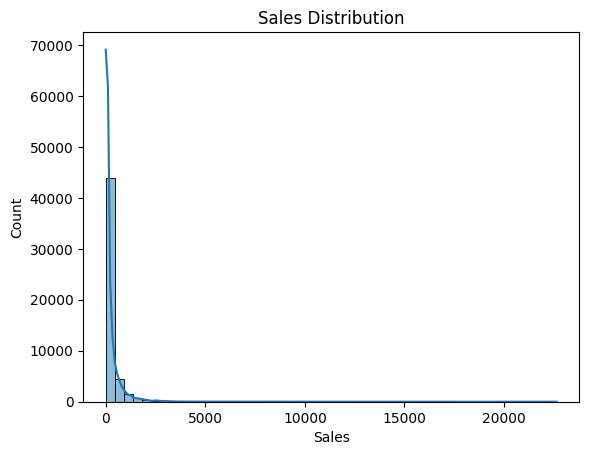

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Checking the distribution of Sales
sns.histplot(clean_df['Sales'], bins=50, kde=True)
plt.title("Sales Distribution")
plt.show()

##Insight for sales
Most values very close to zero and a long tail toward large values (up to ~22000). This means Sales is not normal and not uniform. It is strongly right-skewed

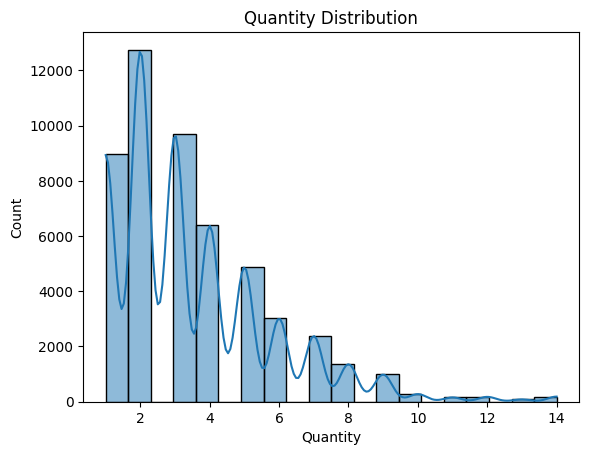

In [ ]:
#cheking distribution of quantity

sns.histplot(clean_df['Quantity'], bins=20, kde=True)
plt.title("Quantity Distribution")
plt.show()

Insight for Quantity

Quantity ranges roughly from 1 to 14. The distribution gradually decreases as quantity increases. It is not perfectly normal, but it is relatively balanced compared to the other variables.

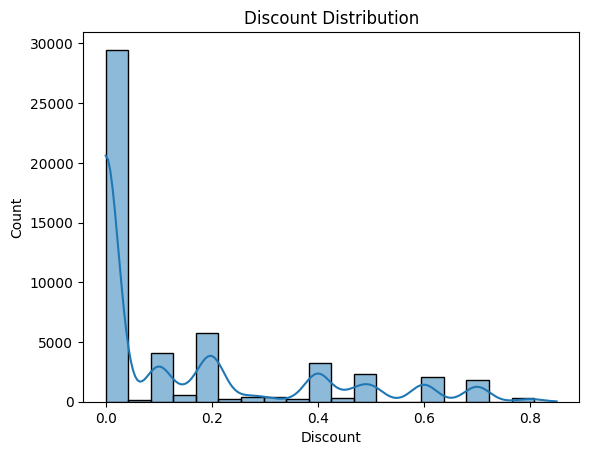

In [ ]:
#checking distribution for Discount
sns.histplot(clean_df['Discount'], bins=20, kde=True)
plt.title("Discount Distribution")
plt.show()

Insight for Discount

Discount has many values near 0 and fewer values at higher discount levels. The bars appear in separate peaks because discount is applied in specific levels (0, 0.1, 0.2 etc.). This means it is not normally distributed and not uniform.


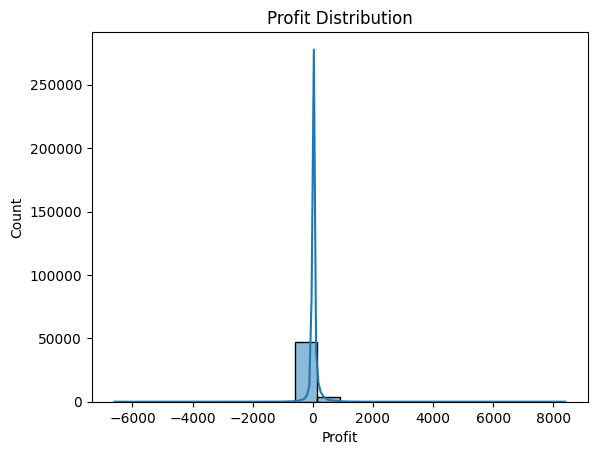

In [ ]:
#checking distribution for Profit
sns.histplot(clean_df['Profit'], bins=20, kde=True)
plt.title("Profit Distribution")
plt.show()

Insight for profit

Profit has many values around zero with both negative and positive extremes. The distribution is not symmetric, and the long tails indicate skewness and outliers. So it is not normally distributed.

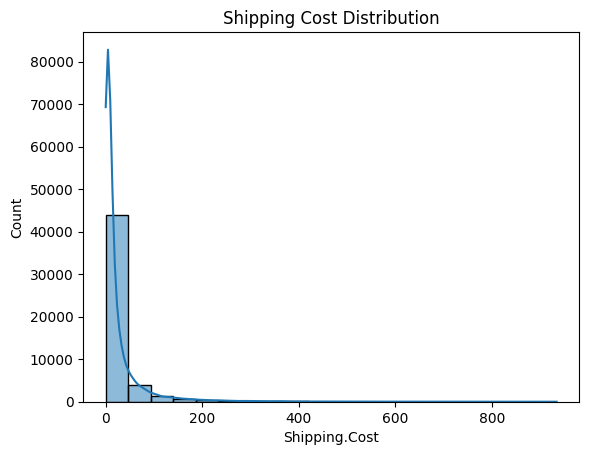

In [ ]:
#checking distribution for Shipping cost
sns.histplot(clean_df['Shipping.Cost'], bins=20, kde=True)
plt.title("Shipping Cost Distribution")
plt.show()

Insight for Shipping Cost

Many small values and a long tail toward high values. This indicates strong right skewness, not normal or uniform.

Q2 ii Overall Insight

Histogram analysis shows that none of the numerical features follow a perfectly normal or uniform distribution. Sales and Shipping Cost exhibit strong right-skewed distributions, where most values are small and a few transactions have extremely large values. Profit also shows skewness with both positive and negative extremes. Quantity displays a relatively more balanced distribution compared to other variables but still shows mild right skew. Discount values appear in discrete levels rather than forming a continuous distribution

#Q2 iii. Which features are right-skewed/left-skewed? What does this signify?

In [ ]:
df[['Sales','Profit','Discount','Quantity','Shipping.Cost']].skew()

,0
Sales,8.137981
Profit,4.157189
Discount,1.387775
Quantity,1.360368
Shipping.Cost,5.862968


Skewness analysis shows that all numerical features exhibit positive skewness. Sales (8.14) and Shipping Cost (5.86) are highly right-skewed, indicating that most transactions involve relatively small values while a few orders generate extremely large sales or shipping costs. Profit (4.16) also shows strong right skewness with both positive and negative extremes, suggesting variability in transaction profitability. Discount (1.39) and Quantity (1.36) display moderate right skewness, indicating that lower discounts and smaller quantities are more common than higher values.

##This pattern suggests that the majority of purchases are small-scale transactions, while a limited number of high-value orders contribute significantly to total sales and shipping costs

#Q2 iv.Which features have a high number of outliers, and discuss the impact.

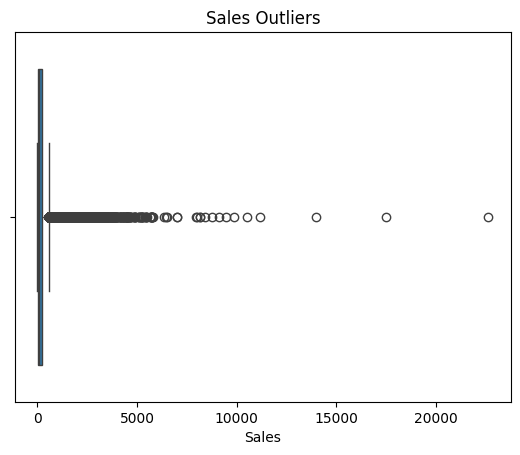

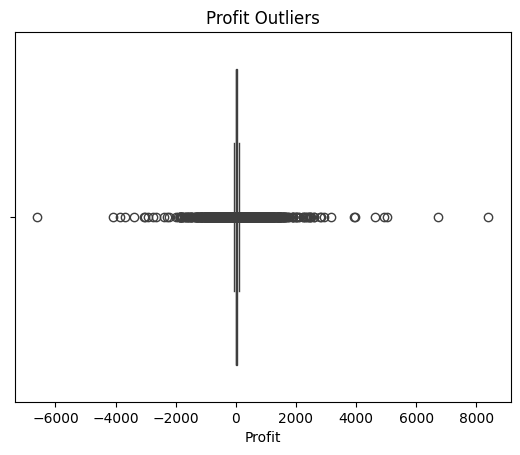

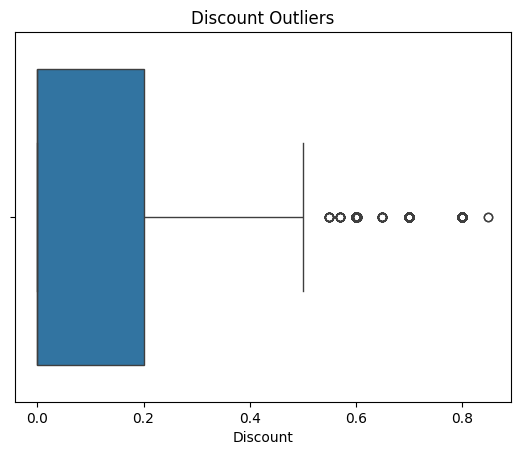

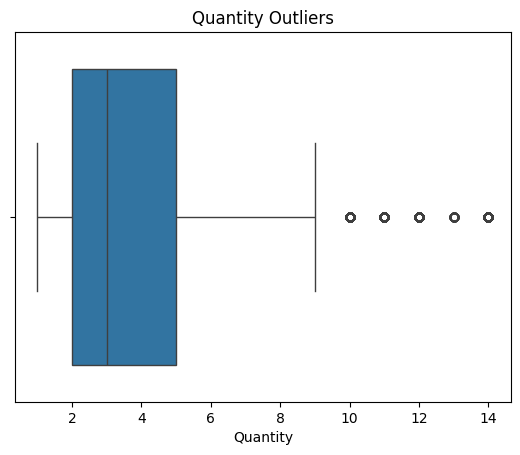

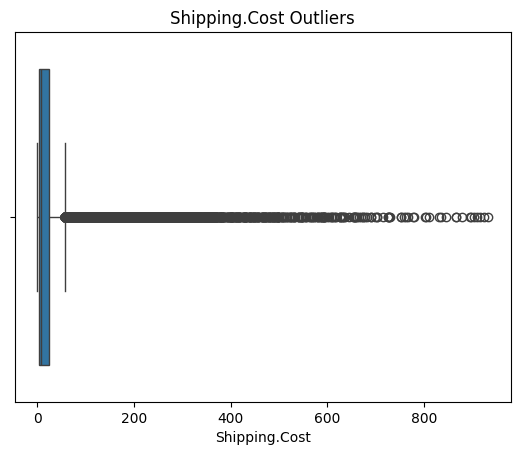

In [ ]:
for col in ['Sales','Profit','Discount','Quantity','Shipping.Cost']:
    sns.boxplot(x=clean_df[col])
    plt.title(col + " Outliers")
    plt.show()

#Q2 iv

Insight:
##For discounts
The box plots shows that

Max discount = 0.85 (85%)

75% = 0.20 (20%)

This means most orders have small discounts, but a few orders have discount greater than 50%

##For Profits

This means at least 25% of orders made zero or negative profit and very few items garnered huge profit

##For quantity

This tells us orders are usually small quantity purchases.

##For sales

The box plot shows that 75% of customer are low-value customers and there are a few high value customers

##for shipping cost

The shipping cost is normal for 75% of customers but there are huge shipping cost for a few which could be due to shipping mode,or volume of items, or weight of items, it should be further investigated

Sales, Profit, and Shipping Cost exhibit a high number of outliers, as indicated by the large difference between their upper quartile values and maximum values. These outliers represent unusually large transactions or extreme profit and loss cases. While they increase variability and may influence statistical measures, they likely represent real business events and therefore were retained in the analysi

##Q 3: Perform Univariate Analysis across all categorical features.

1. Which features seem inaccurate and are not useful as categorical “insights” directly?

2. hat’s the issue with treating Customer? Name as a categorical feature for
modeling?

3. Is the Category distribution balanced or skewed? Give a 1-line reason.

4. In Country, does one country dominate strongly? What does that imply about
geographic bias?   

5. Is the City dataset concentrated in a few cities or spread out?

In [ ]:
clean_df.columns

Index(['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name',
       'Discount', 'Market', 'Order.Date', 'Order.ID', 'Order.Priority',
       'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Sales',
       'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State',
       'Sub.Category', 'Year', 'Market2', 'weeknum'],
      dtype='object')

##Q3 i. Which features seem inaccurate and are not useful as categorical “insights” directly?

Columns like Customer ID, Order ID, and Row ID are not useful for categorical analysis because they represent unique identifiers rather than categories with repeated patterns. Also customer name also cannot be used for categorical insight as there will be many customers with same name, even if customer names are unique also the same problem exists.

In [ ]:
clean_df['Customer.Name'].nunique()


795

In [ ]:
clean_df['Customer.Name'].count()

np.int64(51290)

#Q3 ii What’s the issue with treating Customer? Name as a categorical feature for modeling?

1. Customer Name has extremely high cardinality because there can be a large number of customers in the dataset, and each name may appear once or multiple times. Treating it as a categorical feature would create too many categories, which increases model complexity and may lead to overfitting.

2. customer names are not reliable identifiers since different individuals may share the same name. Because of this, using Customer Name as a categorical feature can lead to ambiguity and inaccurate analysis, making it unsuitable for modeling purposes.

       
#Q3 iii Is the Category distribution balanced or skewed? Give a 1-line reason.

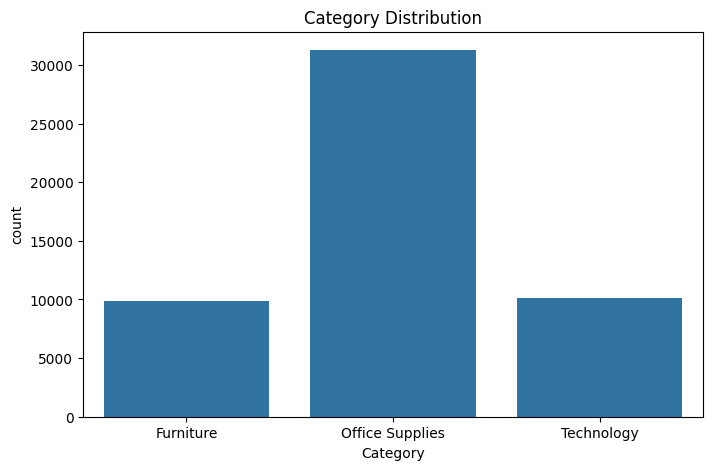

In [ ]:
#plotting the category distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Category', data=clean_df)
plt.title("Category Distribution")
plt.show()

In [ ]:
clean_df['Category'].value_counts()

,count
Category,
Office Supplies,31273
Technology,10141
Furniture,9876


The Category distribution is skewed because Office Supplies dominates the dataset with a significantly higher number of transactions compared to Furniture and Technology.

#Q3 iv In Country, does one country dominate strongly? What does that imply about geographic bias?

In [ ]:
clean_df['Country'].value_counts()

,count
Country,
United States,9994
Australia,2837
France,2827
Mexico,2644
Germany,2065
...,...
Eritrea,2
Burundi,2
Chad,2


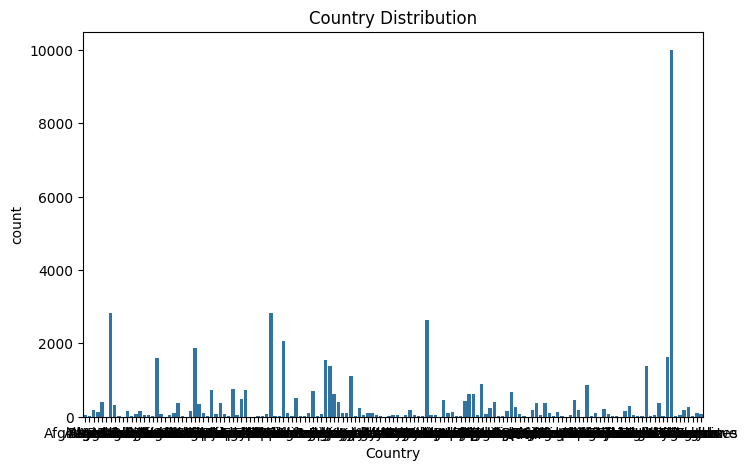

In [ ]:
#plotting the country distribution
plt.figure(figsize=(8,5))
sns.countplot(x='Country', data=clean_df)
plt.title("Country Distribution")
plt.show()

Insight:

As per the data, United States dominates the market.If one country dominates the dataset, it indicates geographic bias, meaning the dataset mainly represents transactions from that country and may not generalize well to other markets.”

#Q3 v Is the City dataset concentrated in a few cities or spread out?

In [ ]:
clean_df['City'].nunique()


3636

In [ ]:
clean_df['City'].value_counts().head(10)

,count
City,
New York City,915
Los Angeles,747
Philadelphia,537
San Francisco,510
Santo Domingo,443
Manila,432
Seattle,428
Houston,377
Tegucigalpa,362


Insight:

Total unique cities = 3,636

Even the top city (New York City) has only 915 records out of 51,290 rows

The dataset is widely spread across many cities, with 3,636 unique cities. Although a few major cities such as New York City and Los Angeles have higher transaction counts, sales are generally distributed across a large number of locations rather than being concentrated in only a few cities

Q 4: Perform Bivariant Analysis for numerical-to-numerical features:
          
        
1. Which two features are most strongly correlated?
2. Also name features that are negatively correlated.
3. If your goal is to understand profit, which are the most useful next bivariate checks?
Perform them and give clear insights.
4. Look for Time Effects Clues. Mention any information you find about the time
relationship with any feature.

In [ ]:
num_cols = ['Sales','Profit','Discount','Quantity','Shipping.Cost']

corr_matrix = clean_df[num_cols].corr()
corr_matrix

,Sales,Profit,Discount,Quantity,Shipping.Cost
Sales,1.000000,0.484923,-0.086728,0.313580,0.768073
Profit,0.484923,1.000000,-0.316490,0.104365,0.354441
Discount,-0.086728,-0.316490,1.000000,-0.019875,-0.079061
Quantity,0.313580,0.104365,-0.019875,1.000000,0.272644
Shipping.Cost,0.768073,0.354441,-0.079061,0.272644,1.000000


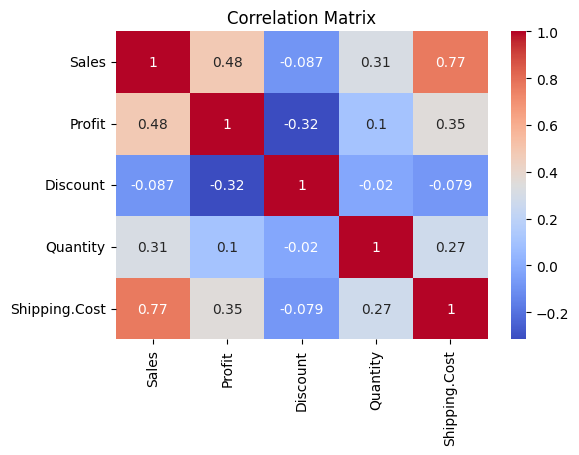

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#Q4  i Which two features are most strongly correlated?

Sales ↔ Shipping Cost = 0.77

This is a strong positive correlation.

Sales and Shipping Cost show the strongest positive correlation (0.77), indicating that larger sales transactions are usually associated with higher shipping costs, likely because larger or heavier orders require greater shipping expenses.


Sales ↔ Profit = 0.48

This is a moderate positive relationship.

Sales and Profit also show a moderate positive correlation (0.48), suggesting that higher sales generally lead to higher profits.

#Q4 ii Name features that are negatively correlated.



Discount ↔ Profit = -0.32

This means when discount increases, profit tends to decrease.

Discount and Profit show a negative correlation (-0.32), indicating that higher discounts tend to reduce profitability.

#Q4 iii. your goal is to understand profit, which are the most useful next bivariate checks? Perform them and give clear insights.

The variables most related to Profit are:

• Sales (0.48)
• Discount (-0.32)
• Shipping Cost (0.35)

So the best relationships to analyze are:

##Profit vs Sales


Profit tends to increase as sales increase, although the relationship is moderate rather than extremely strong.

##Profit vs Discount

Higher discount levels are associated with lower profits, indicating that aggressive discounting may negatively impact profitability.

##Profit vs Shipping Cost

Shipping cost shows a moderate positive correlation with profit (0.35), suggesting that higher-value orders with larger shipping costs may also generate higher profits.


#Q4 iv. Look for Time Effects Clues. Mention any information you find about the time relationship with any feature.

We can check the whether sales , profit and shipping cost have changed over time

In [ ]:
##Checking if sales,profit has increased or decreased over time
clean_df.groupby('Year')[['Sales','Profit']].sum()


,Sales,Profit
Year,,
2011,2259511,248940.81154
2012,2677493,307415.27910
2013,3405860,406935.23018
2014,4300041,504165.97046


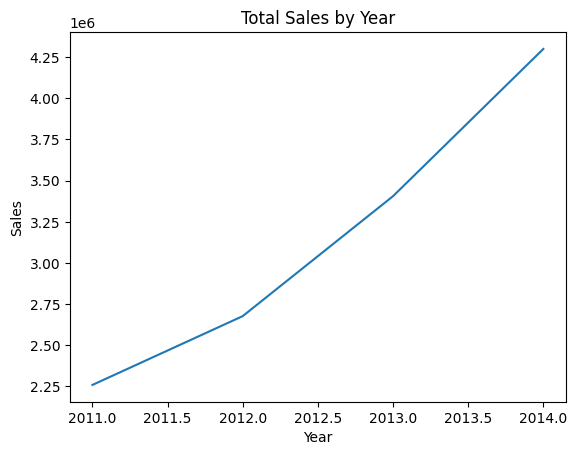

In [ ]:
#plotting total sales per year
year_sales = clean_df.groupby('Year')['Sales'].sum().reset_index()

sns.lineplot(x='Year', y='Sales', data=year_sales)
plt.title("Total Sales by Year")
plt.show()

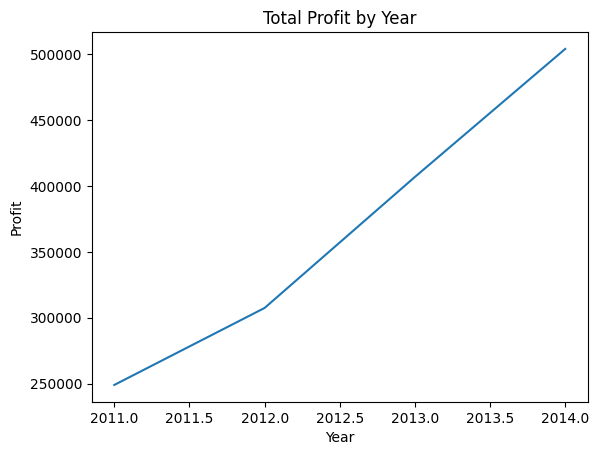

In [ ]:
#plotting if profit has increased over time
year_profit = clean_df.groupby('Year')['Profit'].sum().reset_index()

sns.lineplot(x='Year', y='Profit', data=year_profit)
plt.title("Total Profit by Year")
plt.show()

In [ ]:
#checking if shipping cost increased or decreased over time
clean_df.groupby('Year')['Shipping.Cost'].sum()

,Shipping.Cost
Year,
2011,244279.75550
2012,283490.82400
2013,364546.85436
2014,460522.25454


In [ ]:
#checking if shipping cost per order increased over time

clean_df.groupby('Year')['Shipping.Cost'].mean()

,Shipping.Cost
Year,
2011,27.148228
2012,25.861232
2013,26.418353
2014,26.269024


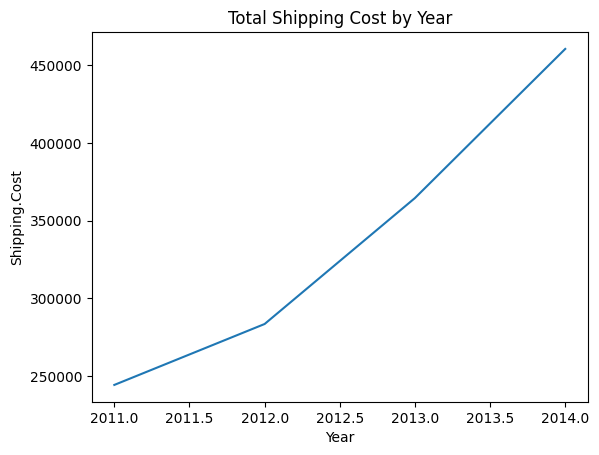

In [ ]:
#plotting if shipping cost has increased or decreased over time
year_shipping = clean_df.groupby('Year')['Shipping.Cost'].sum().reset_index()

sns.lineplot(x='Year', y='Shipping.Cost', data=year_shipping)
plt.title("Total Shipping Cost by Year")
plt.show()

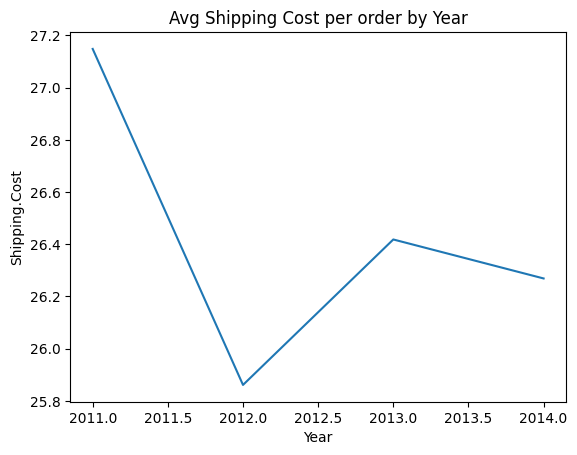

In [ ]:
#plotting if avg shipping cost has increased or decreased over time
year_shipping_mean = clean_df.groupby('Year')['Shipping.Cost'].mean().reset_index()

sns.lineplot(x='Year', y='Shipping.Cost', data=year_shipping_mean)
plt.title("Avg Shipping Cost per order by Year")
plt.show()

Insight:

Time-based analysis indicates a clear upward trend in both Sales and Profit from 2011 to 2014. Sales increased consistently each year, and Profit followed a similar pattern, suggesting steady business growth and improved financial performance over time.

In contrast, the average Shipping Cost per order shows a slight decrease after 2011 and remains relatively stable in the following years. This indicates that although the company processed more orders and generated higher sales, the cost per shipment did not increase proportionally. This may suggest improved logistics efficiency or optimized shipping operations.

Overall, the dataset shows growing sales and profitability over time while maintaining relatively stable average shipping costs, indicating efficient operational management during business expansion.

#Q 5: Perform Bi-variant Analysis for categorical to numerical features.:

1. Profit by Category: Which category has the highest median profit? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?

2. Sales by Category: Which category has the highest median sales? Does it also have the highest median profit?

3. Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers?

4. Sales by Segment: Which segment has the highest median sales? Is the profit
pattern consistent with sales?

In [ ]:
#checking the median of profit
clean_df.groupby('Category')['Profit'].median()

/tmp/ipykernel_963/2952205970.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('Category')['Profit'].median()


,Profit
Category,
Furniture,15.5022
Office Supplies,6.5538
Technology,29.9400


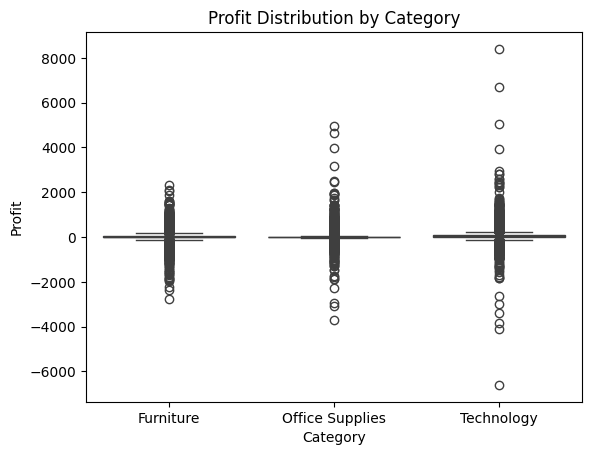

In [ ]:
sns.boxplot(x='Category', y='Profit', data=clean_df)
plt.title("Profit Distribution by Category")
plt.show()

In [ ]:
iqr_profit = clean_df.groupby('Category')['Profit'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
iqr_profit

/tmp/ipykernel_963/1395006797.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  iqr_profit = clean_df.groupby('Category')['Profit'].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))


,Profit
Category,
Furniture,81.535
Office Supplies,20.130
Technology,98.350


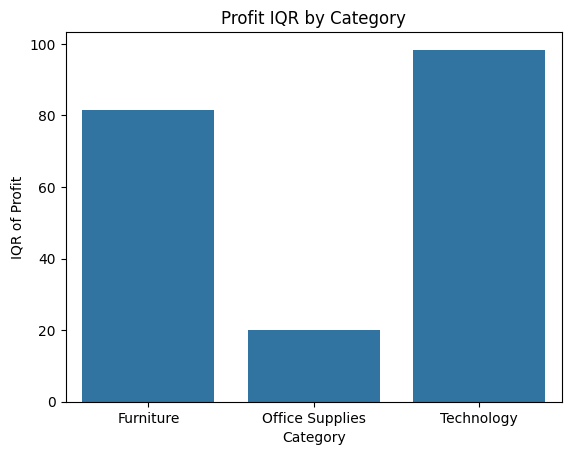

In [ ]:
sns.barplot(x=iqr_profit.index, y=iqr_profit.values)

plt.title("Profit IQR by Category")
plt.xlabel("Category")
plt.ylabel("IQR of Profit")

plt.show()

#Q5 i.Profit by Category: Which category has the highest median profit? Which has the lowest? Which category shows the widest spread (largest IQR) in Profit? What does that suggest about profit consistency?

Insight:

The Technology category has the highest median profit, while Furniture has the lowest median profit. Furniture also shows the widest spread in profit values, indicating greater variability and less consistency in profitability compared to other categories.

The Technology category shows the widest spread in profit with the largest interquartile range (IQR = 98.35), indicating high variability in profitability across its transactions. This suggests that Technology products can generate both relatively low and very high profits. In contrast, Office Supplies has the smallest IQR (20.13), indicating more consistent and stable profit value

In [ ]:
#checking median of sales

clean_df.groupby('Category')['Sales'].median()

/tmp/ipykernel_963/1497645941.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('Category')['Sales'].median()


,Sales
Category,
Furniture,220.0
Office Supplies,46.0
Technology,260.0


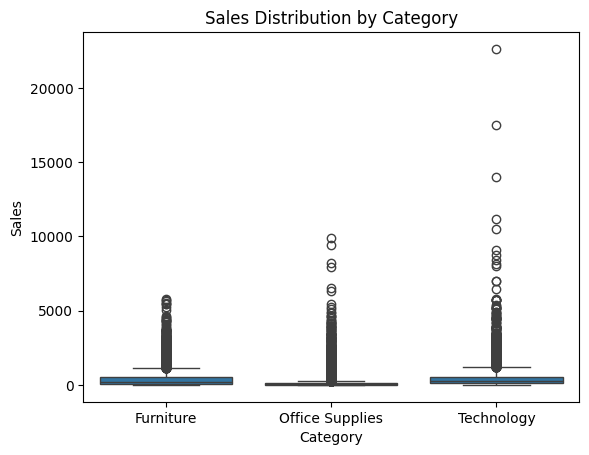

In [ ]:
sns.boxplot(x='Category', y='Sales', data=clean_df)
plt.title("Sales Distribution by Category")
plt.show()

#Q5 ii.Sales by Category: Which category has the highest median sales? Does it also have the highest median profit?

Insight:

Technology has the highest median sales and also the highest median profit,suggesting that high-value products contribute significantly to revenue

In [ ]:
#checking the highest median profit based on segment

clean_df.groupby('Segment')['Profit'].describe()

/tmp/ipykernel_963/2396950819.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('Segment')['Profit'].describe()


,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Consumer,26518.0,28.254008,174.006045,-6599.978,0.0,9.1800,36.6525,6719.9808
Corporate,15429.0,28.596042,177.156362,-4088.376,0.0,9.3152,36.9450,8399.9760
Home Office,9343.0,29.648847,170.577590,-3399.980,0.0,9.3200,37.0800,3919.9888


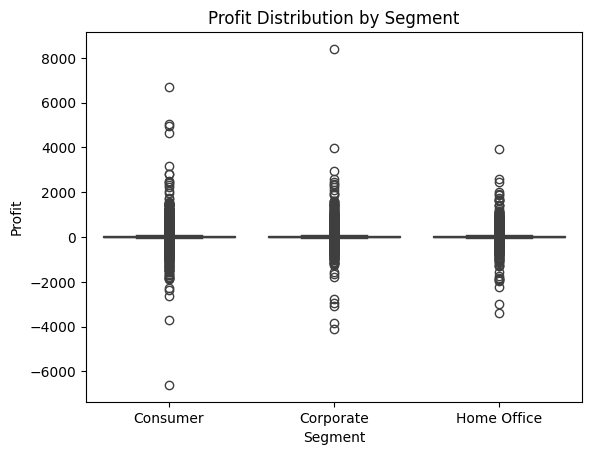

In [ ]:
sns.boxplot(x='Segment', y='Profit', data=clean_df)
plt.title("Profit Distribution by Segment")
plt.show()

#Q5 iii. Profit by Segment: Which segment has the highest median profit? Which segment has the most negative/low profit outliers?

Insight:

The Home Office segment shows the highest median profit, indicating slightly better typical profitability compared to other segments. However, the Consumer segment contains the most negative profit outliers, suggesting that some consumer transactions resulted in substantial losses

In [ ]:
#checking the highest median sales based on segment

clean_df.groupby('Segment')['Sales'].describe()

/tmp/ipykernel_963/3732778155.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby('Segment')['Sales'].describe()


,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
Consumer,26518.0,245.423524,477.135009,0.0,31.0,85.0,251.0,14000.0
Corporate,15429.0,247.897336,486.046561,1.0,31.0,85.0,253.0,17500.0
Home Office,9343.0,247.239217,518.436832,1.0,30.0,85.0,249.0,22638.0


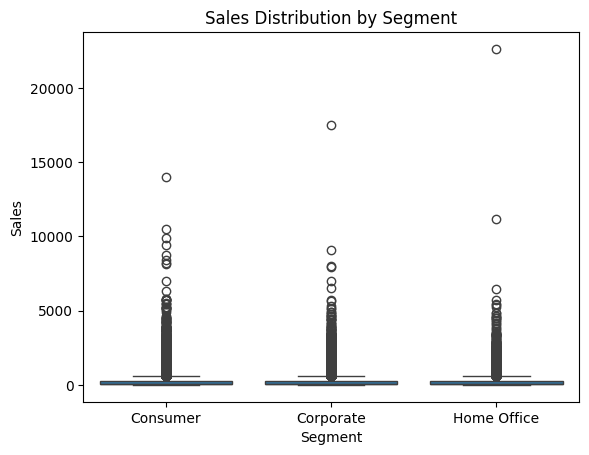

In [ ]:
sns.boxplot(x='Segment', y='Sales', data=clean_df)
plt.title("Sales Distribution by Segment")
plt.show()

#Q5 iv.Sales by Segment: Which segment has the highest median sales? Is the profit pattern consistent with sales?

Insight:

All three segments have the same median sales value (85).

This means the typical transaction value is similar across all segments. Profit pattern is almost consistent with sales

median sales are identical across segments, Home Office has the highest extreme  profit, suggesting slightly better profitability for similar sales levels.

However, the Consumer segment experiences larger negative profit outliers, meaning high sales do not always translate to profit in that segment.


#Q 6: Perform Bivariate Analysis for Market features against Region, Category, and Country:

1. Is the Market is not randomly spread across all Regions?
       
2. Which country has negligible office supply orders?

3. What are the most useful insights?

In [ ]:
#Checking if market randomly spread across regions

pd.crosstab(clean_df['Market'], clean_df['Region'])

Region,Africa,Canada,Caribbean,Central,Central Asia,EMEA,East,North,North Asia,Oceania,South,Southeast Asia,West
Market,,,,,,,,,,,,,
APAC,0,0,0,0,2048,0,0,0,2338,3487,0,3129,0
Africa,4587,0,0,0,0,0,0,0,0,0,0,0,0
Canada,0,384,0,0,0,0,0,0,0,0,0,0,0
EMEA,0,0,0,0,0,5029,0,0,0,0,0,0,0
EU,0,0,0,5822,0,0,0,2141,0,0,2037,0,0
LATAM,0,0,1690,2972,0,0,0,2644,0,0,2988,0,0
US,0,0,0,2323,0,0,2848,0,0,0,1620,0,3203


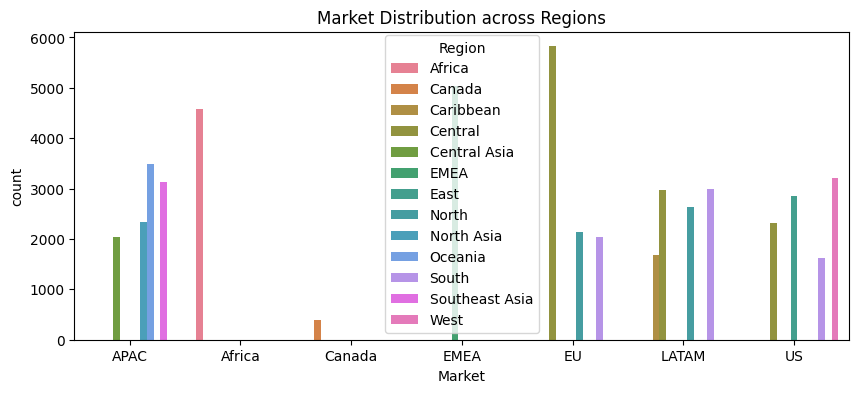

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='Market', hue='Region', data=clean_df)
plt.title("Market Distribution across Regions")
plt.show()

#Q6 i. Is the Market is not randomly spread across all Regions?

Insight:

The Market variable is not randomly distributed across regions. Each market is concentrated in specific geographic regions. For example, the APAC market appears only in Asian and Oceania regions, while the US market is restricted to North American regions. This indicates that markets represent geographically defined business segments rather than random distributions

In [ ]:
#checking the market of furniture,office supplies and technology
pd.crosstab(clean_df['Market'], clean_df['Category'])


Category,Furniture,Office Supplies,Technology
Market,,,
APAC,2429,6177,2396
Africa,631,3045,911
Canada,42,277,65
EMEA,770,3297,962
EU,1501,6589,1910
LATAM,2382,5862,2050
US,2121,6026,1847


In [ ]:
market_category = pd.crosstab(clean_df['Market'], clean_df['Category'])

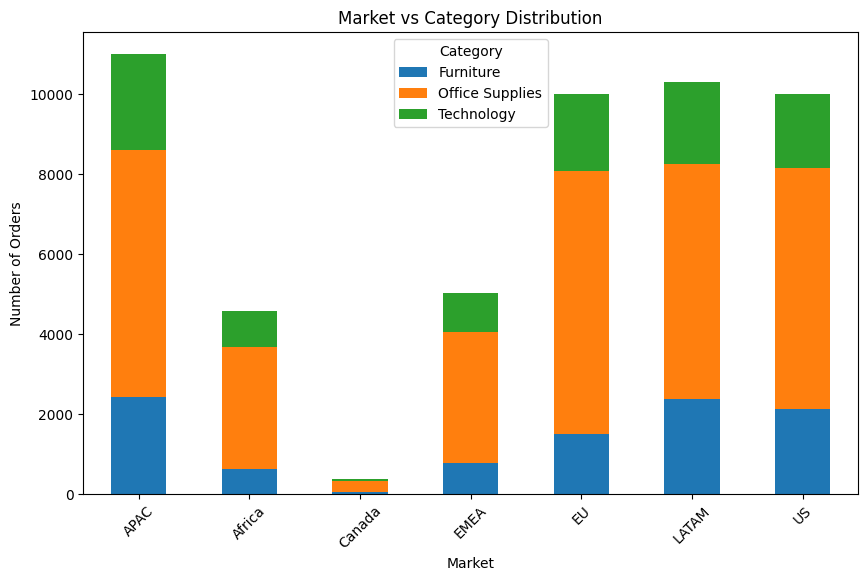

In [ ]:
#cheking market vs Category distribution

market_category.plot(kind='bar', stacked=True, figsize=(10,6))

plt.title("Market vs Category Distribution")
plt.xlabel("Market")
plt.ylabel("Number of Orders")
plt.legend(title="Category")
plt.xticks(rotation=45)

plt.show()

Insight:

This bar chart shows  markets EU,APAC,US and LATAM market are strong in office supplies category, APAC, LATAM and US  markets are good at Furniture supplies.APAC,LATAM and EU are strong in technology. These category of items from Canada Market has very less traction.

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='Market', hue='Region', data=clean_df)
plt.title("Market Distribution across Regions")
plt.show()

In [ ]:
#checking the market against different countries

pd.crosstab(clean_df['Country'], clean_df['Market'])

Market,APAC,Africa,Canada,EMEA,EU,LATAM,US
Country,,,,,,,
Afghanistan,55,0,0,0,0,0,0
Albania,0,0,0,16,0,0,0
Algeria,0,196,0,0,0,0,0
Angola,0,122,0,0,0,0,0
Argentina,0,0,0,0,0,390,0
...,...,...,...,...,...,...,...
Venezuela,0,0,0,0,0,194,0
Vietnam,265,0,0,0,0,0,0
Yemen,0,0,0,30,0,0,0


       
#Q6 ii. Which country has negligible office supply orders?

In [ ]:
office= clean_df[clean_df['Category']=='Office Supplies']

pd.crosstab(clean_df['Country'], office['Category']).sort_values(by='Office Supplies').head(5)

Category,Office Supplies
Country,
Armenia,1
Bahrain,1
Eritrea,1
Swaziland,1
Equatorial Guinea,2


Insight:

 Aremenia,Bahrain, Eritrea, Swaziland, Equatorial Guines are few among the countries where there is negligible office supply order.

#Q6 iii. Useful insight from this bivariate analysis

Insight:

The analysis shows that markets are not randomly distributed across regions but are geographically structured. Each market corresponds to specific regional groups. Office Supplies is the most frequently purchased category across all markets, indicating consistent global demand for this category. The Canada market shows significantly fewer orders compared to other markets, suggesting a smaller market presence. Additionally, Furniture and Technology orders are lower than Office Supplies across all markets, indicating that these products are purchased less frequently.


Another important insight to take business decision on certain markets to analyze which category of items are sold in that market

The analysis shows that the EU market records the highest number of Office Supplies orders, indicating strong demand for operational products. The APAC market leads in Technology purchases, suggesting higher technology adoption. LATAM demonstrates balanced demand across all product categories, reflecting diversified purchasing behavior. In contrast, the Canada market shows very low order counts across all categories, indicating a relatively small market presence.”
